# Joint choice + RT: `DDMRiskRegressionModel`

The DDM analog of `notebook_1_psychometric.ipynb`. Same data conventions
(presentation order + loss-trial choice flip); now also models reaction
times jointly with choices.

## How probability enters the drift

The drift per trial in bauer's `DDMRiskModel` is

$$
v \;=\; v_{\text{scale}} \cdot \frac{
    \underbrace{(\hat\mu_2 - \hat\mu_1)}_{\text{perceived log-magnitude diff}}
    \;+\;
    \underbrace{\log(p_2 / p_1)}_{\text{log-odds threshold}}
}{
    \sqrt{\sigma_1^2 + \sigma_2^2}
}
$$

— the SNR of the perceived log-EU difference. Two key points:

1. **Probability enters as an additive log-odds shift, not as a
   multiplicative weighting.** The drift is *not* an EV-weighted comparison
   ($p_2 n_2$ vs $p_1 n_1$) — it's the log-magnitude diff **plus a
   constant threshold** $\log(p_2/p_1)$.

2. **Same threshold as the static probit.** Bauer's `RiskModel` decides
   `choose 2 iff post_log_n_2 + log(p_2) > post_log_n_1 + log(p_1)`. The
   DDM just makes the same SNR signal accumulate over time instead of
   feeding it into one $\Phi(\cdot)$ call.

For $p_{\text{risky}} = 0.55$, the log-odds threshold is
$\log(0.55) \approx -0.60$, so the drift starts pushing toward "chose
risky" only when the risky payoff is **at least 60 % bigger** (in
log-units) — i.e. above the EV-neutral threshold.

In [ ]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from helpers import (prepare, plot_forest, plot_subject_panels,
                     per_subject_natural_from_files,
                     chose_risky, log_risky_safe, mark_ev_neutral,
                     GAIN, LOSS, CONDITIONS)

HERE = Path(__file__).parent if '__file__' in dir() else Path('.').resolve()
if not (HERE / 'data' / 'pilot_data.tsv').exists() and (HERE / 'for_alina').exists():
    HERE = HERE / 'for_alina'

### Drift vs log-ratio, by probability

Changing $p_2$ **shifts** the drift-vs-log-ratio curve horizontally — it
does **not** scale it. That's the additive-threshold interpretation
visualised.

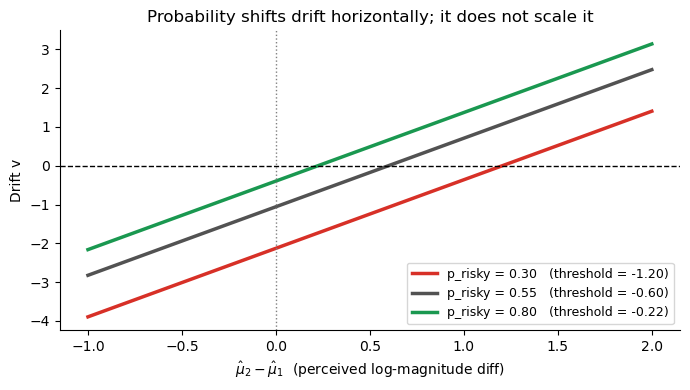

In [ ]:
log_ratio = np.linspace(-1, 2, 200)
sigma = 0.4
denom = np.sqrt(2 * sigma**2)

fig, ax = plt.subplots(figsize=(7, 4))
for p_risky, c in [(0.30, '#d73027'), (0.55, '#525252'), (0.80, '#1a9850')]:
    v = (log_ratio + np.log(p_risky / 1.0)) / denom
    ax.plot(log_ratio, v, color=c, lw=2.5,
            label=f'p_risky = {p_risky:.2f}   (threshold = {np.log(p_risky):+.2f})')
ax.axhline(0, ls='--', c='black', lw=1); ax.axvline(0, ls=':', c='gray', lw=1)
ax.set_xlabel(r'$\hat\mu_2 - \hat\mu_1$  (perceived log-magnitude diff)')
ax.set_ylabel('Drift v')
ax.set_title('Probability shifts drift horizontally; it does not scale it')
ax.legend(fontsize=9); sns.despine()
plt.tight_layout()

## Load + prepare the pilot data

Same convention as the psychometric notebook: keep `n1, n2, p1, p2` in
presentation order, flip `choice` on loss trials, and drop trials with
fast RTs (HSSM's WFPT likelihood floors at $\log L = -66.1$ with **zero
gradient** for `rt < t0`, which traps NUTS).

In [ ]:
df_raw = pd.read_csv(HERE / 'data' / 'pilot_data.tsv', sep='\t').set_index(['subject', 'trial'])
RT_FLOOR, RT_CEILING = 0.20, 5.0
df_raw = df_raw[(df_raw['rt'] >= RT_FLOOR) & (df_raw['rt'] <= RT_CEILING)]
df = prepare(df_raw)
print(f'{df.index.get_level_values("subject").nunique()} subjects, {len(df)} trials')
print(f'Mean RT by domain: {df.groupby("domain")["rt"].mean().round(3).to_dict()}')

2 subjects, 697 trials
Mean RT by domain: {'gain': 0.61, 'loss': 0.653}


### Chronometric × psychometric

The **chronometric** curve (RT vs evidence strength) is the DDM
signature: RTs are slowest at the indifference point (where drift ≈ 0
and the accumulator dawdles) and fast far from it. That's the joint
information the DDM exploits beyond a static psychometric.

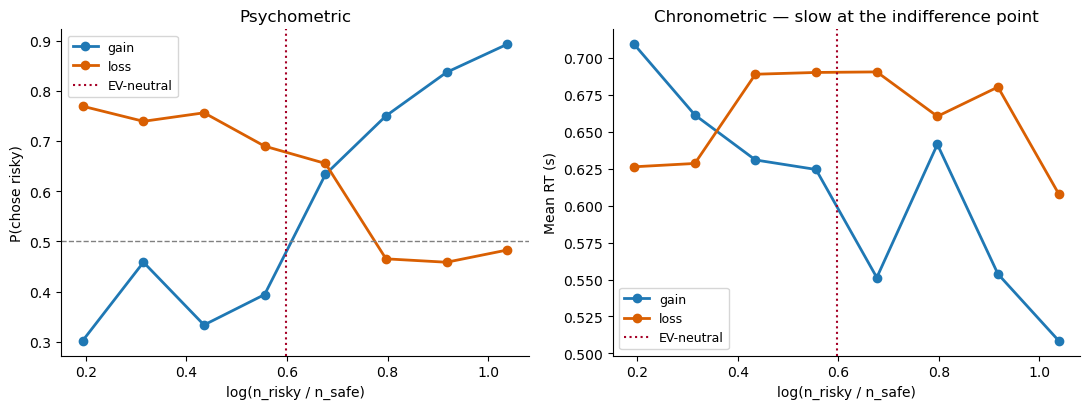

In [ ]:
df_plot = df.reset_index()
df_plot['log_ratio']   = log_risky_safe(df_plot)
df_plot['chose_risky'] = chose_risky(df_plot, 'choice', flipped=True)
df_plot['bin'] = pd.cut(df_plot['log_ratio'], bins=8).map(lambda x: x.mid).astype(float)

grp = (df_plot.groupby(['domain', 'bin'])
       .agg(p_risky=('chose_risky', 'mean'),
            rt=('rt', 'mean'),
            n=('chose_risky', 'size'))
       .reset_index().query('n >= 10'))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
for ax, var, label in [(axes[0], 'p_risky', 'P(chose risky)'),
                        (axes[1], 'rt',      'Mean RT (s)')]:
    for dom, c in [('gain', GAIN), ('loss', LOSS)]:
        d = grp[grp['domain'] == dom]
        ax.plot(d['bin'], d[var], 'o-', color=c, label=dom, lw=2)
    mark_ev_neutral(ax)
    ax.set_xlabel('log(n_risky / n_safe)'); ax.set_ylabel(label)
    ax.legend(fontsize=9); sns.despine(ax=ax)
axes[0].axhline(0.5, ls='--', c='gray', lw=1); axes[0].set_title('Psychometric')
axes[1].set_title('Chronometric — slow at the indifference point')
plt.tight_layout()

## Fit the DDM (hierarchical)

```bash
ssh sciencecluster '
    cd ~/git/bauer/examples/for_alina &&
    sbatch slurm/run_ddm.sh'                 # hierarchical by default
rsync sciencecluster:git/bauer/examples/for_alina/results/ddm_idata.nc ./results/
```

`fit_ddm.py` fits **one hierarchical model** (partial pooling across subjects):

```python
DDMRiskRegressionModel(
    paradigm=df,                              # all subjects together
    regressors={'n1_evidence_sd': 'C(domain)',
                'n2_evidence_sd': 'C(domain)',
                'a':              'C(domain)'},   # t0 NOT regressed (motor delay)
    prior_estimate='full', fit_seperate_evidence_sd=True,
    fit_v_scale=False, fix_z=True,
)
model.build_estimation_model(data=df, hierarchical=True)
```

Free parameters: group-level means (`*_mu`) + per-subject offsets for the
encoding noise (`n1/n2_evidence_sd`) and boundary `a` — all regressed on
`domain` — plus a single non-decision time `t0` and the Bayesian-observer
prior params.

> **Why this converges even at N=2:** bauer's *starting-point finder* is on by
> default for DDM models. It starts each chain at a data-informed plausible
> value (`find_MAP`) dispersed by a fraction of each parameter's prior SD —
> so chains sit around the typical set, not all at the mode. Without it,
> hierarchical-DDM convergence is a seed lottery; with it this fit lands at
> r̂≈1.00. At N=2 the *group* posterior is naturally wide (only two subjects
> inform it), but partial pooling is the right structure for real data and
> tightens as subjects come in. (`--per-subject` opts out; rarely what you
> want.) `t0` is not regressed — it's motor delay, with no reason to differ
> by domain, and regressing it just adds an unidentified parameter.

Bauer's risky-DDM has **no explicit risk-premium parameter**; apparent risk
attitudes emerge from encoding-noise × prior-shrinkage (the KLW mechanism).

In [ ]:
from bauer.models import DDMRiskRegressionModel

regressors = {'n1_evidence_sd': 'C(domain)',
              'n2_evidence_sd': 'C(domain)',
              'a':              'C(domain)'}
model = DDMRiskRegressionModel(
    paradigm=df.reset_index(), regressors=regressors,
    prior_estimate='full', fit_seperate_evidence_sd=True,
    fit_v_scale=False, fix_z=True)
model.build_estimation_model(data=df, hierarchical=True)

idata = az.from_netcdf(HERE / 'results' / 'ddm_idata.nc')
s = az.summary(idata, var_names=['n1_evidence_sd_mu', 'n2_evidence_sd_mu',
                                 'a_mu', 't0_mu'], round_to=3)
print(f"group-level: max r̂={s['r_hat'].max():.3f}, min ESS={s['ess_bulk'].min():.0f}")

group-level: max r̂=1.002, min ESS=1270


## Group-level posteriors

Forest plot of the group-level (`*_mu`) coefficients. For each regressed
parameter, the `domain[T.loss]` entry is the gain→loss contrast; if its 94%
HDI excludes 0, that parameter differs by domain at the population level.
(At N=2 these are wide — that's honest.)

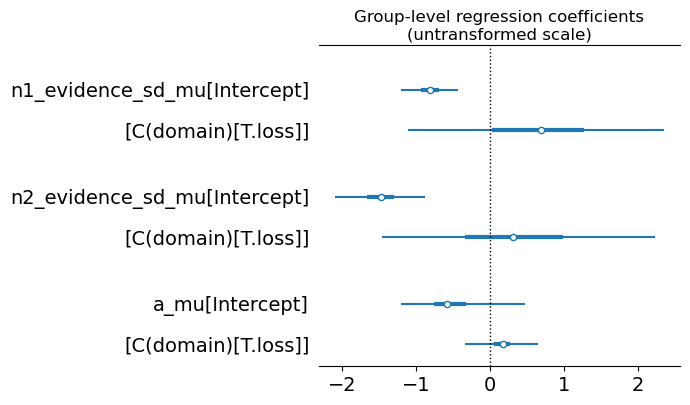

In [ ]:
az.plot_forest(idata, var_names=['n1_evidence_sd_mu', 'n2_evidence_sd_mu', 'a_mu'],
               combined=True, hdi_prob=0.94, figsize=(7, 4))
plt.axvline(0, color='black', ls=':', lw=1)
plt.title('Group-level regression coefficients (untransformed scale)')
plt.tight_layout()

## Natural-scale estimates by domain

`model.get_conditionwise_parameters` rebuilds the design matrix at the
conditions you pass, multiplies in the posterior coefficients, and applies
the link function — so the result is in natural units. `group=True` gives the
population value; pass `group=False` for per-subject estimates.

     parameter domain   mean     lo     hi
n1_evidence_sd   gain 0.3711 0.2609 0.4963
n1_evidence_sd   loss 0.7096 0.1235 1.6854
n2_evidence_sd   gain 0.2135 0.1194 0.3577
n2_evidence_sd   loss 0.3641 0.0406 1.1141
             a   gain 0.5062 0.2852 1.0867
             a   loss 0.5765 0.2722 1.2628


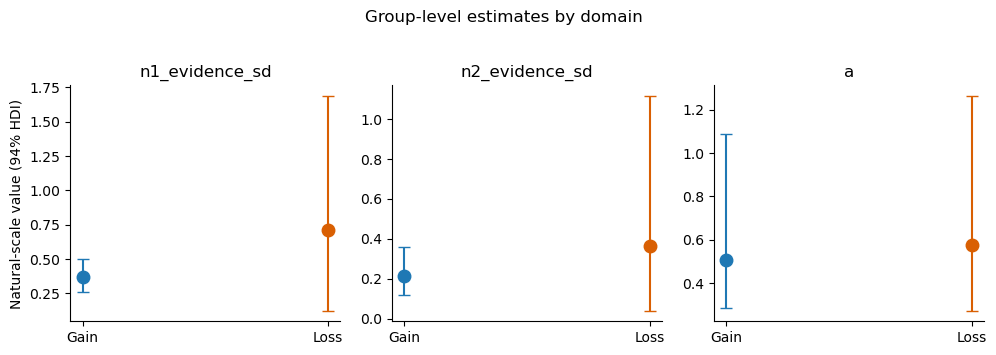

In [ ]:
conditions = pd.DataFrame({'domain': ['gain', 'loss']})
rows = []
for par in ['n1_evidence_sd', 'n2_evidence_sd', 'a']:
    cp = model.get_conditionwise_parameters(idata, conditions, group=True).loc[par]
    for i, dom in enumerate(['gain', 'loss']):
        v = cp.iloc[:, i].values
        rows.append(dict(parameter=par, domain=dom, mean=v.mean(),
                         lo=np.percentile(v, 3), hi=np.percentile(v, 97)))
natural = pd.DataFrame(rows)
print(natural.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
for ax, par in zip(axes, ['n1_evidence_sd', 'n2_evidence_sd', 'a']):
    d = natural[natural.parameter == par]
    for i, dom in enumerate(['gain', 'loss']):
        r = d[d.domain == dom].iloc[0]
        ax.errorbar(i, r['mean'], yerr=[[r['mean'] - r['lo']], [r['hi'] - r['mean']]],
                    fmt='o', ms=9, color=GAIN if dom == 'gain' else LOSS, capsize=4)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Gain', 'Loss'])
    ax.set_title(par); sns.despine(ax=ax)
axes[0].set_ylabel('Natural-scale value (94% HDI)')
plt.suptitle('Group-level estimates by domain', y=1.03); plt.tight_layout()

## Posterior predictive: choices and RTs together

The DDM PPC gives joint `(simulated_rt, simulated_choice)` per trial per
posterior draw. Points = data, bands = 94% PPC interval, split by domain.

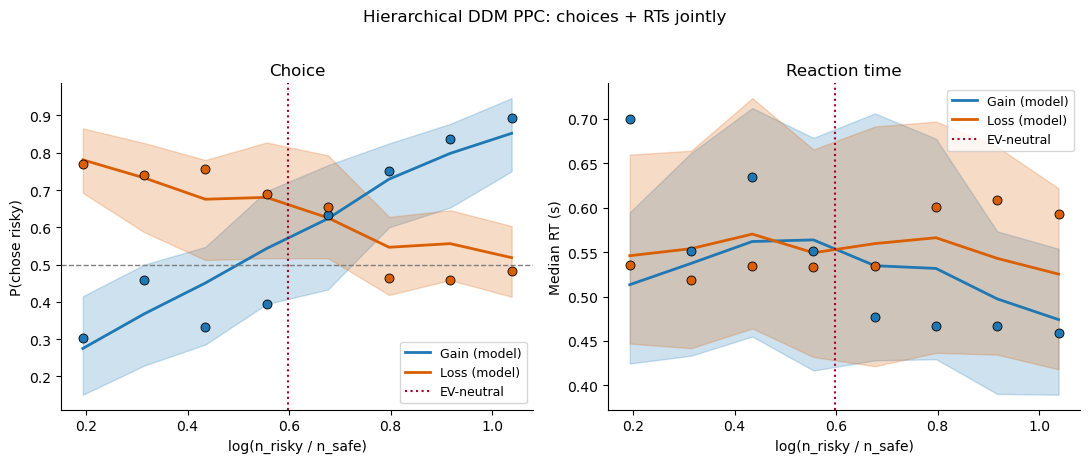

In [ ]:
ppc = model.ppc(df, idata, n_posterior_samples=100, random_seed=0, progressbar=False)
ppc = ppc.join(df[['n1', 'n2', 'p1', 'p2', 'domain']], how='left')
ppc['log_ratio'] = log_risky_safe(ppc)
ppc['sim_chose_risky'] = chose_risky(ppc, 'simulated_choice', flipped=True)

edges = np.linspace(ppc['log_ratio'].min(), ppc['log_ratio'].max(), 9)
def _bin(x): return pd.cut(x, edges, include_lowest=True).map(lambda v: v.mid).astype(float)
ppc['bin'] = _bin(ppc['log_ratio'])

per = (ppc.groupby(['domain', 'bin', 'ppc_sample'])
       .agg(p=('sim_chose_risky', 'mean'), rt=('simulated_rt', 'median')).reset_index())
def _lo(x): return az.hdi(x.values, hdi_prob=0.94)[0]
def _hi(x): return az.hdi(x.values, hdi_prob=0.94)[1]
mod = (per.groupby(['domain', 'bin'])
       .agg(p=('p', 'mean'), p_lo=('p', _lo), p_hi=('p', _hi),
            rt=('rt', 'mean'), rt_lo=('rt', _lo), rt_hi=('rt', _hi)).reset_index())

obs = df.reset_index()
obs['log_ratio'] = log_risky_safe(obs)
obs['chose_risky'] = chose_risky(obs, 'choice', flipped=True)
obs['bin'] = _bin(obs['log_ratio'])
od = (obs.groupby(['domain', 'bin'])
      .agg(p_obs=('chose_risky', 'mean'), rt_obs=('rt', 'median')).reset_index())
merged = mod.merge(od, on=['domain', 'bin'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (lo_c, hi_c, pred, obs_c, title) in zip(
        axes, [('p_lo', 'p_hi', 'p', 'p_obs', 'Choice'),
               ('rt_lo', 'rt_hi', 'rt', 'rt_obs', 'Reaction time')]):
    for dom, c in [('gain', GAIN), ('loss', LOSS)]:
        d = merged[merged.domain == dom].sort_values('bin')
        ax.fill_between(d['bin'], d[lo_c], d[hi_c], color=c, alpha=0.22)
        ax.plot(d['bin'], d[pred], color=c, lw=2, label=f'{dom.capitalize()} (model)')
        ax.scatter(d['bin'], d[obs_c], color=c, s=42, edgecolor='black',
                   linewidth=0.6, zorder=5)
    ax.set_xlabel('log(n_risky / n_safe)'); ax.set_title(title)
    mark_ev_neutral(ax); sns.despine(ax=ax); ax.legend(fontsize=9)
axes[0].axhline(0.5, ls='--', c='gray', lw=1)
axes[0].set_ylabel('P(chose risky)'); axes[1].set_ylabel('Median RT (s)')
plt.suptitle('Hierarchical DDM PPC: choices + RTs jointly', y=1.02); plt.tight_layout()

## Adapting to your data

Same drop-in recipe as the psychometric notebook. The DDM needs:

- `rt` in **seconds** as a column.
- All trials with `rt > t0_prior_centre ≈ 0.20 s` (drop the rest). The
  `fit_ddm.py --rt-floor` flag does this.

If you want a richer model:

| Goal | How |
|------|-----|
| Test gain-vs-loss noise difference | already in `fit_ddm.py` |
| Test gain-vs-loss boundary `a`     | already in `fit_ddm.py` |
| Allow per-domain prior shrinkage   | add `'risky_prior_sd': 'C(domain)'` etc. |
| Stimulus-dependent noise (Weber)   | switch to `DDMFlexibleNoiseRiskRegressionModel` |